In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [55]:
user_train = df.groupby(['id_user', 'city', 'gender']).agg({'mon':'count', 'cnt_indiv':'sum', 'cnt_total':'sum', 'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})
user_train.head()

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,female,9,33,33,58600
1,1001,Москва,female,11,23,129,124800
2,1002,Москва,male,11,64,128,166000
3,1004,Екатеринбург,male,9,18,18,32000
4,1005,СПб,female,2,7,7,12600


In [49]:
big_cnt_indiv = user_train.loc[user_train['cnt_indiv'] / user_train['cnt_total'] > .7].copy()
big_cnt_indiv.head(10) 

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,female,9,33,33,58600
3,1004,Екатеринбург,male,9,18,18,32000
4,1005,СПб,female,2,7,7,12600
6,1007,Москва,female,4,5,5,9000
8,1009,Москва,female,4,9,9,16200
11,1012,Москва,female,2,6,6,10800
15,1016,Москва,female,1,4,4,7200
16,1017,СПб,female,1,6,6,10800
17,1018,Екатеринбург,female,4,18,18,32400
18,1019,Москва,male,7,31,31,55000


In [56]:
big_cnt_indiv['avg_check_per_mon'] = big_cnt_indiv['sum_total'] / big_cnt_indiv['nmonths']
big_cnt_indiv['avg_train_per_mon'] = big_cnt_indiv['cnt_indiv'] / big_cnt_indiv['nmonths']
big_cnt_indiv.head()

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total,avg_check_per_mon,avg_train_per_mon
0,1000,СПб,female,9,33,33,58600,6511.111111,3.666667
3,1004,Екатеринбург,male,9,18,18,32000,3555.555556,2.000000
4,1005,СПб,female,2,7,7,12600,6300.000000,3.500000
6,1007,Москва,female,4,5,5,9000,2250.000000,1.250000
8,1009,Москва,female,4,9,9,16200,4050.000000,2.250000


In [57]:
city_g_stats = big_cnt_indiv.groupby(['city', 'gender']).agg({'id_user':'nunique', 'avg_check_per_mon':'mean', 'avg_train_per_mon':'mean'}).reset_index().rename(columns = {'id_user':'nusers'})
city_g_stats

,city,gender,nusers,avg_check_per_mon,avg_train_per_mon
0,Екатеринбург,female,12,5391.746032,3.009524
1,Екатеринбург,male,12,5832.394180,3.256184
2,Казань,female,8,6297.500000,3.412500
3,Казань,male,12,5229.378307,2.931548
4,Москва,female,118,5565.425624,3.132836
5,Москва,male,59,6915.316115,3.872733
6,СПб,female,32,6093.278770,3.399777
7,СПб,male,28,5024.889456,2.821443


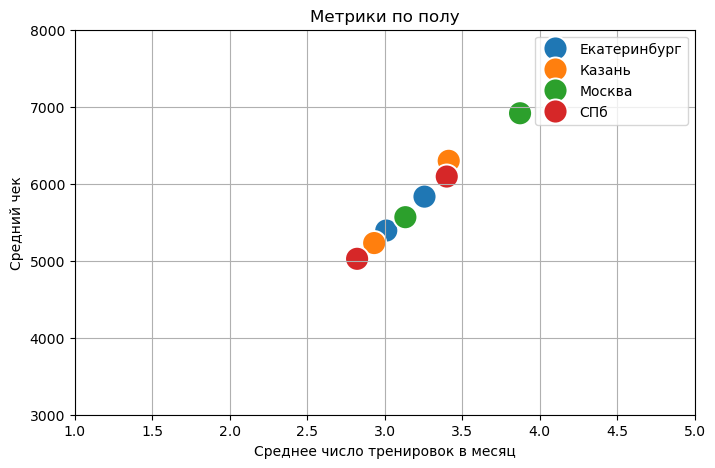

In [76]:
plt.figure(figsize = (8,5))
sns.scatterplot(data = city_g_stats,x = 'avg_train_per_mon',y = 'avg_check_per_mon',hue = 'city',s = 300)
plt.xlim(1,5)
plt.ylim(3000,8000)
plt.xlabel('Среднее число тренировок в месяц')
plt.ylabel('Средний чек')
plt.title('Метрики по городам')
plt.legend()
plt.grid(True)
plt.show()

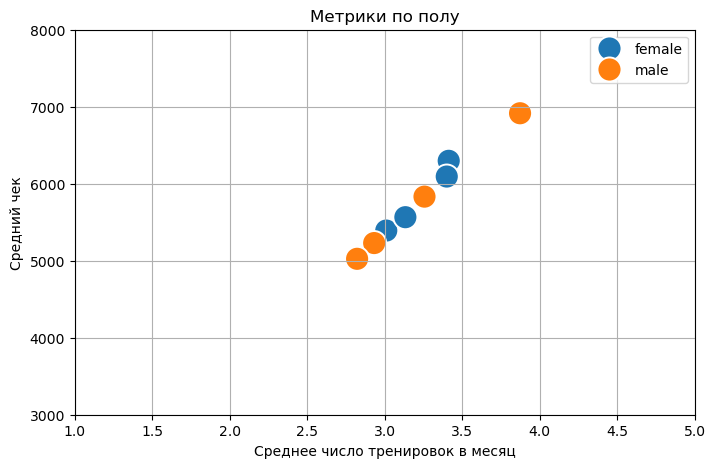

In [77]:
plt.figure(figsize = (8,5))
sns.scatterplot(data = city_g_stats,x = 'avg_train_per_mon',y = 'avg_check_per_mon',hue = 'gender',s = 300)
plt.xlim(1,5)
plt.ylim(3000,8000)
plt.xlabel('Среднее число тренировок в месяц')
plt.ylabel('Средний чек')
plt.title('Метрики по полу')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#1. Мужчины / женщины с СПб, Казани и Екатеринбурга, которые 3 раза в месяц ходят на тренировку, тратят 6т.р.
#2. Нет.
#3. около 6т.р.

### Задача 2. Топ-10 клиентов

In [78]:
df

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4586,1997,2023-08,4,0,3200,0,4,3200,2023-01,2023-12,СПб,58.0,male
4587,1997,2023-09,6,0,4800,0,6,4800,2023-01,2023-12,СПб,58.0,male
4588,1997,2023-10,6,0,4800,0,6,4800,2023-01,2023-12,СПб,58.0,male
4589,1997,2023-11,6,0,4800,0,6,4800,2023-01,2023-12,СПб,58.0,male


In [79]:
df_gr = df.groupby('id_user').agg({'cnt_total':'sum'}).reset_index().sort_values('cnt_total', \
                            ascending = False).head(10)
df_gr

,id_user,cnt_total
319,1381,159
12,1013,151
551,1657,144
420,1506,138
780,1929,130
1,1001,129
474,1570,129
2,1002,128
485,1582,127
168,1194,127


In [80]:
user_lst = df_gr['id_user'].tolist()
user_lst

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1582, 1194]

In [83]:
df_top = df[df['id_user'].isin(user_lst)]
df_top.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
10,1001,2023-02,11,3,8800,5400,14,14200,2023-01,2023-12,Москва,35.0,female
11,1001,2023-03,8,6,6400,10800,14,17200,2023-01,2023-12,Москва,35.0,female
12,1001,2023-04,9,5,7200,9000,14,16200,2023-01,2023-12,Москва,35.0,female
13,1001,2023-05,3,7,2400,11200,10,13600,2023-01,2023-12,Москва,35.0,female


In [85]:
user_top = df_top.groupby(['id_user', 'city', 'gender']).agg({'cnt_total':'sum'}).reset_index()
user_top

,id_user,city,gender,cnt_total
0,1001,Москва,female,129
1,1002,Москва,male,128
2,1013,Москва,male,151
3,1194,СПб,female,127
4,1381,Москва,female,159
5,1506,Москва,female,138
6,1570,Екатеринбург,male,129
7,1582,Екатеринбург,male,127
8,1657,СПб,male,144
9,1929,Москва,male,130


In [86]:
user_top['city'].value_counts()

city
Москва          6
СПб             2
Екатеринбург    2
Name: count, dtype: int64

In [87]:
user_top['gender'].value_counts()

gender
male      6
female    4
Name: count, dtype: int64

In [ ]:
#1. В Москве больше всего, в 3 раза меньше в СПб и Ек.
#2. В большей степени мужчины, женщин на 3 меньше.

### Задача 3. Динамика клиентской базы

In [92]:
df.head(20)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
5,1000,2023-08,0,3,0,5400,3,5400,2023-03,2023-12,СПб,44.0,female
6,1000,2023-09,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
7,1000,2023-11,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
8,1000,2023-12,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female


In [136]:
new_clients = df.groupby(['id_user']).agg({'mon': 'min'}).reset_index()
new_clients_cnt = new_clients.groupby('mon').agg(cnt_new_users =  ('id_user', 'count')).reset_index()
new_clients_cnt

,mon,cnt_new_users
0,2023-01,337
1,2023-02,88
2,2023-03,83
3,2023-04,62
4,2023-05,57
5,2023-06,51
6,2023-07,48
7,2023-08,35
8,2023-09,28
9,2023-10,27


In [101]:
active_clients = df.groupby(['mon']).agg(active_users = ('id_user', 'nunique')).reset_index()
active_clients

,mon,active_users
0,2023-01,337
1,2023-02,350
2,2023-03,355
3,2023-04,345
4,2023-05,360
5,2023-06,383
6,2023-07,412
7,2023-08,423
8,2023-09,429
9,2023-10,441


In [137]:
dep_clients = df.groupby('id_user').agg({'mon': 'max'}).reset_index()
dep_clients_cnt = dep_clients.groupby('mon').agg(cnt_dep_users =  ('id_user', 'count')).reset_index()
dep_clients_cnt

,mon,cnt_dep_users
0,2023-01,15
1,2023-02,22
2,2023-03,37
3,2023-04,21
4,2023-05,21
5,2023-06,13
6,2023-07,33
7,2023-08,33
8,2023-09,55
9,2023-10,101


In [138]:
total_data = pd.merge(pd.merge(new_clients_cnt, dep_clients_cnt, on = 'mon'), active_clients, on = 'mon')
total_data

,mon,cnt_new_users,cnt_dep_users,active_users
0,2023-01,337,15,337
1,2023-02,88,22,350
2,2023-03,83,37,355
3,2023-04,62,21,345
4,2023-05,57,21,360
5,2023-06,51,13,383
6,2023-07,48,33,412
7,2023-08,35,33,423
8,2023-09,28,55,429
9,2023-10,27,101,441


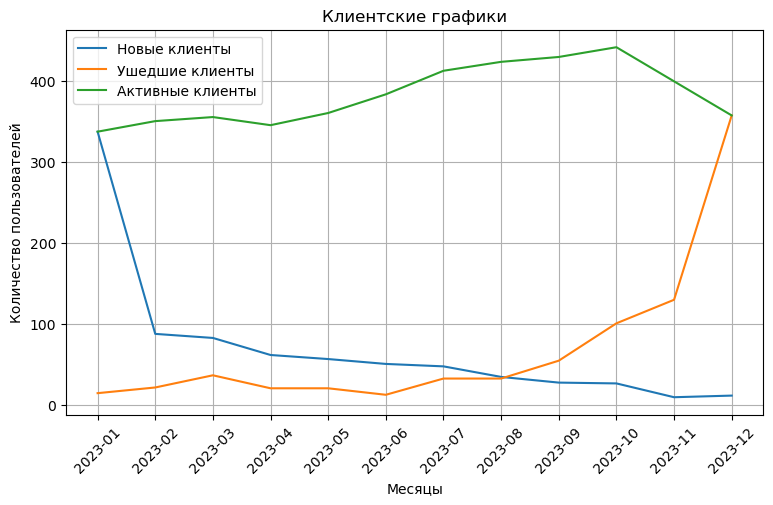

In [150]:
plt.figure(figsize = (9,5))
sns.lineplot(data = total_data, x='mon', y='cnt_new_users', label='Новые клиенты')
sns.lineplot(data = total_data, x='mon', y='cnt_dep_users', label='Ушедшие клиенты')
sns.lineplot(data = total_data, x='mon', y='active_users', label='Активные клиенты')
plt.legend()
plt.grid(True)
plt.xlabel('Месяцы')
plt.ylabel('Количество пользователей')
plt.title('Клиентские графики')
plt.xticks(rotation = 45)
plt.show()